# Test1 --- Poisson Neural Likelihood Estimation 

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
params = np.loadtxt("/Users/chang/data/px2cosmo/test1/mock1_N50000.counts_params.dat")
counts = np.loadtxt("/Users/chang/data/px2cosmo/test1/mock1_N50000.counts.dat")

In [6]:
params.shape

(50000, 4)

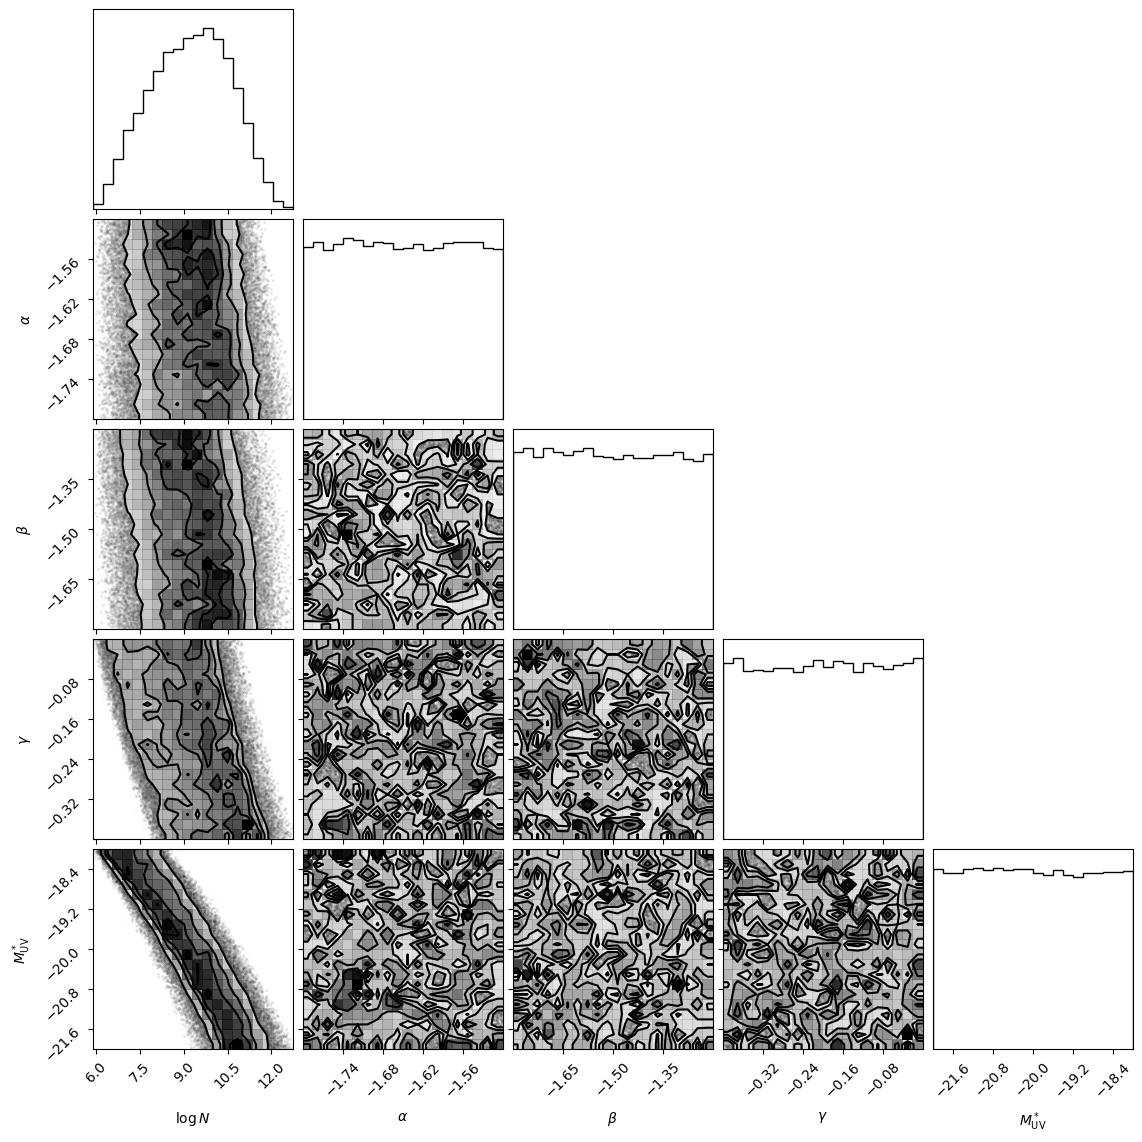

In [8]:
fig = DFM.corner(np.hstack([np.log(counts)[:,None], params]), 
                 labels=[r'$\log N$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'])

In [9]:
ishuffle = np.arange(params.shape[0])
np.random.shuffle(ishuffle)

In [11]:
_phi = torch.tensor(params[ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32))#.to('mps')
_logcounts = torch.tensor(np.log(counts)[ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32)[:,None])#.to('mps')

In [18]:
inference = NPE(density_estimator='nsf')#, device='mps')
_ = inference.append_simulations(_logcounts, _phi).train()

 Neural network successfully converged after 74 epochs.

In [19]:
p_logN_phi = inference.build_posterior()

## validate

In [20]:
test_phi = torch.tensor(params[ishuffle][int(counts.shape[0]*0.9):].astype(np.float32))#.to('mps')
test_logcounts = torch.tensor(np.log(counts)[ishuffle][int(counts.shape[0]*0.9):].astype(np.float32)[:,None])#.to('mps')

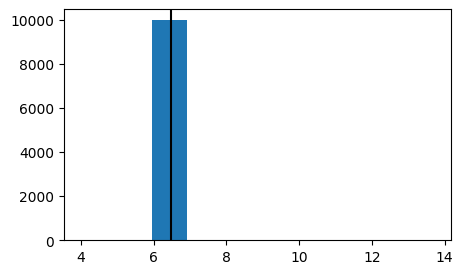

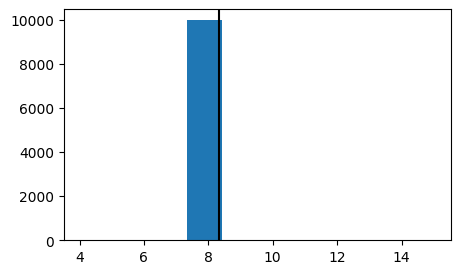

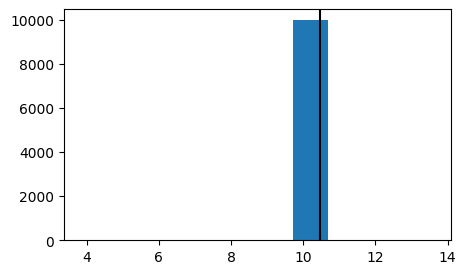

In [21]:
for i in range(3):
    samples = p_logN_phi.sample((10000,), x=test_phi[i], show_progress_bars=False).cpu()
    plt.figure(figsize=(5,3))
    plt.hist(samples.numpy())
    plt.axvline(test_logcounts[i].cpu(), c='k')
    plt.show()

In [22]:
ranks = [] 
for i in np.arange(test_phi.shape[0])[::10]:
    samples = p_logN_phi.sample((10000,), x=test_phi[i], show_progress_bars=False).cpu().numpy()
    ranks.append(np.mean(samples < test_logcounts.numpy()[i]))

(array([0.9336412 , 0.99387612, 1.03001707, 1.05812669, 1.04407188,
        1.05411103, 1.1043068 , 1.03804839, 0.92159422, 0.8613593 ]),
 array([0.0015 , 0.10111, 0.20072, 0.30033, 0.39994, 0.49955, 0.59916,
        0.69877, 0.79838, 0.89799, 0.9976 ]),
 <BarContainer object of 10 artists>)

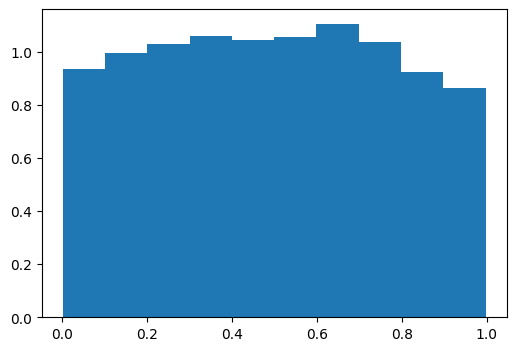

In [23]:
plt.figure(figsize=(6,4))
plt.hist(ranks, density=True)    

In [25]:
torch.save(p_logN_phi, '/Users/chang/data/px2cosmo/test1/p_logN_phi.pt')